# RL Classic control



## Mountain Car Continuous

### local environment

In [1]:
print("hi from py")

hi from py


In [4]:
from __future__ import absolute_import, division, print_function

import base64
import imageio
import IPython  
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import PIL.Image
import pyvirtualdisplay
import reverb

import tensorflow as tf
import gym # 0.23.1 is required

# To get smooth animations
import matplotlib.animation as animation
matplotlib.rc('animation', html='jshtml')

from tf_agents.agents.dqn import dqn_agent
from tf_agents.drivers import py_driver
from tf_agents.environments import suite_gym
from tf_agents.environments import tf_py_environment
from tf_agents.eval import metric_utils
from tf_agents.metrics import tf_metrics
from tf_agents.networks import sequential
from tf_agents.policies import py_tf_eager_policy
from tf_agents.policies import random_tf_policy
from tf_agents.replay_buffers import reverb_replay_buffer
from tf_agents.replay_buffers import reverb_utils
from tf_agents.trajectories import trajectory
from tf_agents.specs import tensor_spec
from tf_agents.utils import common

from tf_agents.environments import  suite_gym
from tf_agents.environments.atari_preprocessing import AtariPreprocessing
from tf_agents.environments.atari_wrappers import FrameStack4
import gym

# To get smooth animations
import matplotlib.animation as animation
matplotlib.rc('animation', html='jshtml')



2025-12-02 06:05:43.003935: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-02 06:05:43.961177: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-02 06:05:43.961709: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-02 06:05:43.961937: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-02 06:05:44.031356: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-02 06:05:44.034582: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

here, we set up a virtual display for rendering OpenAI gym ENVIRONMENTS

In [5]:
gpus = tf.config.list_physical_devices('GPU')

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
        print('\nMemory growth activado para', gpu)
    except Exception as e:
        print('\nNo se pudo activar memory growth para', gpu, '->', e)


2025-12-02 06:06:16.194796: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-12-02 06:06:16.197822: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### hyperparameters definition

In [6]:
num_iterations = 20000  # more updates for the continuous task

initial_collect_steps = 500  # gather a buffer of transitions before training
collect_steps_per_iteration = 4  # short on-policy rollouts per update
replay_buffer_max_length = 200000  # room to keep diverse trajectories

batch_size = 128  # larger batches stabilize the critic
actor_learning_rate = 1e-4
critic_learning_rate = 3e-4
log_interval = 200  # learner prints ~100 times

num_eval_episodes = 10  # keep eval short
eval_interval = 2000  # evaluate ~10 times during training

target_update_tau = 0.02  # softer target updates avoid divergence
target_update_period = 5
reward_scale_factor = 0.1  # MountainCarContinuous gives sparse +100 reward
gamma = 0.99
ou_stddev = 0.2
ou_damping = 0.15


definimos el entorno especifico para nuestro caso de estudio:

The Mountain Car MDP is a deterministic MDP that consists of a car placed stochastically at the bottom of a sinusoidal valley, with the only possible actions being the accelerations that can be applied to the car in either direction. The goal of the MDP is to strategically accelerate the car to reach the goal state on top of the right hill. There are two versions of the mountain car domain in gymnasium: one with discrete actions and one with continuous. This version is the one with continuous actions.

In [7]:
env_name = 'MountainCarContinuous-v0'
env = suite_gym.load(env_name)

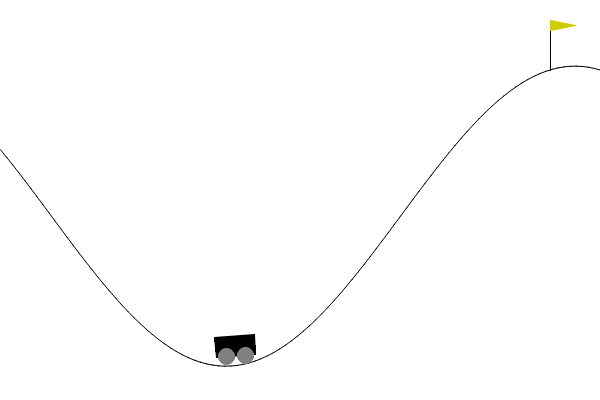

In [8]:
#@test {"skip": true}
env.reset()
PIL.Image.fromarray(env.render())

In [9]:
time_step = env.reset()
print("Time step:")
print(time_step)

# define an continuous action used on the specific environment
action = np.array([0.2], dtype=np.float32)

next_time_step = env.step(action)
print("Next time step:")
print(next_time_step)


Time step:
TimeStep(
{'discount': array(1., dtype=float32),
 'observation': array([-0.46983257,  0.        ], dtype=float32),
 'reward': array(0., dtype=float32),
 'step_type': array(0, dtype=int32)})
Next time step:
TimeStep(
{'discount': array(1., dtype=float32),
 'observation': array([-4.6993405e-01, -1.0150036e-04], dtype=float32),
 'reward': array(-0.004, dtype=float32),
 'step_type': array(1, dtype=int32)})


In [10]:
train_py_env = suite_gym.load(env_name)
eval_py_env = suite_gym.load(env_name)

In [11]:
train_env = tf_py_environment.TFPyEnvironment(train_py_env)
eval_env = tf_py_environment.TFPyEnvironment(eval_py_env)

### model define 

importamos las librerias necesarias para trabajar con el agente DDPG para este caso continuo

In [12]:
from tf_agents.agents.ddpg import ddpg_agent
from tf_agents.agents.ddpg import actor_network, critic_network
from tf_agents.networks import sequential
from tf_agents.policies import actor_policy
from tensorflow.keras.optimizers.legacy import Adam


en lugar de usar una estructura basada en QValues con una QNetwork, trabajmos con redes Actor y Critic para este caso 

In [13]:

actor_net = actor_network.ActorNetwork(
    train_env.observation_spec(),
    train_env.action_spec(),
    fc_layer_params=(256, 256) # change to 64
)

critic_net = critic_network.CriticNetwork(
    (train_env.observation_spec(), train_env.action_spec()),
    joint_fc_layer_params=(256, 256)
)


intiailize an agent

In [14]:
# Use separate optimizer instances for actor and critic to avoid the KeyError
# Ensure we use the legacy Adam optimizer (TF-Agents compatibility).
actor_optimizer = Adam(learning_rate=actor_learning_rate)
critic_optimizer = Adam(learning_rate=critic_learning_rate)

# Build variables for actor and critic so optimizers can register slot variables
# Create small dummy data matching the environment specs to build the networks' variables
obs_spec = train_env.observation_spec()
action_spec = train_env.action_spec()
sample_obs = tf.nest.map_structure(lambda spec: tf.zeros([1] + list(spec.shape), dtype=spec.dtype), obs_spec)
sample_action = tf.nest.map_structure(lambda spec: tf.zeros([1] + list(spec.shape), dtype=spec.dtype), action_spec)
_ = actor_net(sample_obs)
_ = critic_net((sample_obs, sample_action))

# No explicit build() for Keras optimizers - older versions do not expose optimizer.build().
# Creating / calling the models above ensures their variables exist; separate optimizer instances
# avoid 'The optimizer cannot recognize variable' KeyError when updating different networks.

train_step_counter = tf.Variable(0)
agent = ddpg_agent.DdpgAgent(
    time_step_spec=train_env.time_step_spec(),
    action_spec=train_env.action_spec(),
    actor_network=actor_net,
    critic_network=critic_net,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    ou_stddev=ou_stddev,
    ou_damping=ou_damping,
    target_update_tau=target_update_tau,
    target_update_period=target_update_period,
    gamma=gamma,
    reward_scale_factor=reward_scale_factor,
    gradient_clipping=1.0,
    train_step_counter= train_step_counter
)

agent.initialize()

# Diagnostics: print trainable variable names and try one train step (safe try/except).
print("Actor trainable variables (count):", len(actor_net.trainable_variables))
for v in actor_net.trainable_variables:
  print('  ', v.name)
print("Critic trainable variables (count):", len(critic_net.trainable_variables))
for v in critic_net.trainable_variables:
  print('  ', v.name)

# Try a single train call (wrapped) to confirm there is no KeyError.
if 'iterator' in globals():
  try:
    experience, _ = next(iterator)
    train_info = agent.train(experience)
    print("One train step succeeded. Loss =", train_info.loss)
  except Exception as e:
    print("Train step raised:", repr(e))
else:
  print("Iterator not built yet; skip dry-run train step.")


Actor trainable variables (count): 6
   ActorNetwork/input_mlp/dense0/kernel:0
   ActorNetwork/input_mlp/dense0/bias:0
   ActorNetwork/input_mlp/dense1/kernel:0
   ActorNetwork/input_mlp/dense1/bias:0
   ActorNetwork/action/kernel:0
   ActorNetwork/action/bias:0
Critic trainable variables (count): 6
   CriticNetwork/joint_mlp/dense0/kernel:0
   CriticNetwork/joint_mlp/dense0/bias:0
   CriticNetwork/joint_mlp/dense1/kernel:0
   CriticNetwork/joint_mlp/dense1/bias:0
   CriticNetwork/value/kernel:0
   CriticNetwork/value/bias:0
Iterator not built yet; skip dry-run train step.


### define policies

es importante definir las policies

In [15]:
eval_policy = agent.policy
collect_policy = agent.collect_policy

a random policy

In [16]:
random_policy = random_tf_policy.RandomTFPolicy(train_env.time_step_spec(),
                                                train_env.action_spec())

get an action from a policy

In [17]:
example_environment = tf_py_environment.TFPyEnvironment(
    suite_gym.load('MountainCarContinuous-v0'))

    

In [18]:
time_step = example_environment.reset()

In [19]:
random_policy.action(time_step)

PolicyStep(action=<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[-0.63055444]], dtype=float32)>, state=(), info=())

### metrics and evaluation

average retunr

In [20]:
#@test {"skip": true}
def compute_avg_return(environment, policy, num_episodes=10):

  total_return = 0.0
  for _ in range(num_episodes):

    time_step = environment.reset()
    episode_return = 0.0

    while not time_step.is_last():
      action_step = policy.action(time_step)
      time_step = environment.step(action_step.action)
      episode_return += time_step.reward
    total_return += episode_return

  avg_return = total_return / num_episodes
  return avg_return.numpy()[0]


# See also the metrics module for standard implementations of different metrics.
# https://github.com/tensorflow/agents/tree/master/tf_agents/metrics

Running this computation on the `random_policy` shows a baseline performance in the environment.

In [21]:
compute_avg_return(eval_env, random_policy, num_eval_episodes)

-33.61657

### Replay Buffer

In order to keep track of the data collected from the environment, we will use [Reverb](https://deepmind.com/research/open-source/Reverb), an efficient, extensible, and easy-to-use replay system by Deepmind. It stores experience data when we collect trajectories and is consumed during training.

This replay buffer is constructed using specs describing the tensors that are to be stored, which can be obtained from the agent using agent.collect_data_spec.


Mountain Car Continuous usa acciones definidas en el espacio continuo, asi que usamos un replay buffer normal aprovechando reverb

In [22]:
table_name = 'uniform_table'
replay_buffer_signature = tensor_spec.from_spec(
      agent.collect_data_spec)
replay_buffer_signature = tensor_spec.add_outer_dim(
    replay_buffer_signature)

table = reverb.Table(
    table_name,
    max_size=replay_buffer_max_length,
    sampler=reverb.selectors.Uniform(),
    remover=reverb.selectors.Fifo(),
    rate_limiter=reverb.rate_limiters.MinSize(1),
    signature=replay_buffer_signature)

reverb_server = reverb.Server([table])

replay_buffer = reverb_replay_buffer.ReverbReplayBuffer(
    agent.collect_data_spec,
    table_name=table_name,
    sequence_length=2,
    local_server=reverb_server)

rb_observer = reverb_utils.ReverbAddTrajectoryObserver(
  replay_buffer.py_client,
  table_name,
  sequence_length=2)

[reverb/cc/platform/tfrecord_checkpointer.cc:162]  Initializing TFRecordCheckpointer in /tmp/tmpgwhqmtqa.
[reverb/cc/platform/tfrecord_checkpointer.cc:565] Loading latest checkpoint from /tmp/tmpgwhqmtqa
[reverb/cc/platform/default/server.cc:71] Started replay server on port 46553


For most agents, `collect_data_spec` is a named tuple called `Trajectory`, containing the specs for observations, actions, rewards, and other items.

In [23]:
agent.collect_data_spec

Trajectory(
{'action': BoundedTensorSpec(shape=(1,), dtype=tf.float32, name='action', minimum=array(-1., dtype=float32), maximum=array(1., dtype=float32)),
 'discount': BoundedTensorSpec(shape=(), dtype=tf.float32, name='discount', minimum=array(0., dtype=float32), maximum=array(1., dtype=float32)),
 'next_step_type': TensorSpec(shape=(), dtype=tf.int32, name='step_type'),
 'observation': BoundedTensorSpec(shape=(2,), dtype=tf.float32, name='observation', minimum=array([-1.2 , -0.07], dtype=float32), maximum=array([0.6 , 0.07], dtype=float32)),
 'policy_info': (),
 'reward': TensorSpec(shape=(), dtype=tf.float32, name='reward'),
 'step_type': TensorSpec(shape=(), dtype=tf.int32, name='step_type')})

see that this are the spec action, policy, rewards, discount, etc.

In [24]:
agent.collect_data_spec._fields

('step_type',
 'observation',
 'action',
 'policy_info',
 'next_step_type',
 'reward',
 'discount')

### Data Collection

Now execute the random policy in the environment for a few steps, recording the data in the replay buffer.

Here we are using 'PyDriver' to run the experience collecting loop. You can learn more about TF Agents driver in our [drivers tutorial](https://www.tensorflow.org/agents/tutorials/4_drivers_tutorial).

In [25]:
#@test {"skip": true}
py_driver.PyDriver(
    train_py_env,
    py_tf_eager_policy.PyTFEagerPolicy(
      random_policy, use_tf_function=True),
    [rb_observer],
    max_steps=initial_collect_steps).run(train_py_env.reset())


(TimeStep(
 {'discount': array(1., dtype=float32),
  'observation': array([-0.5611861 , -0.01611434], dtype=float32),
  'reward': array(-0.05009699, dtype=float32),
  'step_type': array(1, dtype=int32)}),
 ())

aqui, ejecutamos el entorno paso a paso para recolectar experiencias

The replay buffer is now a collection of Trajectories.

In [26]:
# For the curious:
# Uncomment to peel one of these off and inspect it.
iter(replay_buffer.as_dataset()).next()

[reverb/cc/client.cc:165] Sampler and server are owned by the same process (15758) so Table uniform_table is accessed directly without gRPC.


(Trajectory(
 {'action': <tf.Tensor: shape=(2, 1), dtype=float32, numpy=
 array([[0.32609797],
        [0.56540704]], dtype=float32)>,
  'discount': <tf.Tensor: shape=(2,), dtype=float32, numpy=array([1., 1.], dtype=float32)>,
  'next_step_type': <tf.Tensor: shape=(2,), dtype=int32, numpy=array([1, 1], dtype=int32)>,
  'observation': <tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[-0.52735156,  0.00630171],
        [-0.52053255,  0.006819  ]], dtype=float32)>,
  'policy_info': (),
  'reward': <tf.Tensor: shape=(2,), dtype=float32, numpy=array([-0.01063399, -0.03196851], dtype=float32)>,
  'step_type': <tf.Tensor: shape=(2,), dtype=int32, numpy=array([1, 1], dtype=int32)>}),
 SampleInfo(key=<tf.Tensor: shape=(2,), dtype=uint64, numpy=array([7962456352527433659, 7962456352527433659], dtype=uint64)>, probability=<tf.Tensor: shape=(2,), dtype=float64, numpy=array([0.00200401, 0.00200401])>, table_size=<tf.Tensor: shape=(2,), dtype=int64, numpy=array([499, 499])>, priority=<tf.Tens

The agent needs access to the replay buffer. This is provided by creating an iterable `tf.data.Dataset` pipeline which will feed data to the agent.

Each row of the replay buffer only stores a single observation step. But since the DQN Agent needs both the current and next observation to compute the loss, the dataset pipeline will sample two adjacent rows for each item in the batch (`num_steps=2`).

This dataset is also optimized by running parallel calls and prefetching data.

In [27]:
# Dataset generates trajectories with shape [Bx2x...]
dataset = replay_buffer.as_dataset(
    num_parallel_calls=3,
    sample_batch_size=batch_size,
    num_steps=2).prefetch(3)

dataset

<_PrefetchDataset element_spec=(Trajectory(
{'action': TensorSpec(shape=(128, 2, 1), dtype=tf.float32, name=None),
 'discount': TensorSpec(shape=(128, 2), dtype=tf.float32, name=None),
 'next_step_type': TensorSpec(shape=(128, 2), dtype=tf.int32, name=None),
 'observation': TensorSpec(shape=(128, 2, 2), dtype=tf.float32, name=None),
 'policy_info': (),
 'reward': TensorSpec(shape=(128, 2), dtype=tf.float32, name=None),
 'step_type': TensorSpec(shape=(128, 2), dtype=tf.int32, name=None)}), SampleInfo(key=TensorSpec(shape=(128, 2), dtype=tf.uint64, name=None), probability=TensorSpec(shape=(128, 2), dtype=tf.float64, name=None), table_size=TensorSpec(shape=(128, 2), dtype=tf.int64, name=None), priority=TensorSpec(shape=(128, 2), dtype=tf.float64, name=None), times_sampled=TensorSpec(shape=(128, 2), dtype=tf.int32, name=None)))>

In [28]:
iterator = iter(dataset)
print(iterator)

In [29]:
# For the curious:
# Uncomment to see what the dataset iterator is feeding to the agent.
# Compare this representation of replay data 
# to the collection of individual trajectories shown earlier.

# iterator.next()

### Training the agent

Two things must happen during the training loop:

-   collect data from the environment
-   use that data to train the agent's neural network(s)

This example also periodicially evaluates the policy and prints the current score.

The following will take ~5 minutes to run.

In [30]:
#@test {"skip": true}
try:
  %%time
except:
  pass

# (Optional) Optimize by wrapping some of the code in a graph using TF function.
agent.train = common.function(agent.train)

# Reset the train step.
agent.train_step_counter.assign(0)

# Evaluate the agent's policy once before training.
avg_return = compute_avg_return(eval_env, agent.policy, num_eval_episodes)
returns = [avg_return]

# Reset the environment.
time_step = train_py_env.reset()

# Create a driver to collect experience.
collect_driver = py_driver.PyDriver(
    train_py_env,
    py_tf_eager_policy.PyTFEagerPolicy(
      agent.collect_policy, use_tf_function=True),
    [rb_observer],
    max_steps=collect_steps_per_iteration)

for _ in range(num_iterations):

  # Collect a few steps and save to the replay buffer.
  time_step, _ = collect_driver.run(time_step)

  # Sample a batch of data from the buffer and update the agent's network.
  experience, unused_info = next(iterator)
  train_loss = agent.train(experience).loss

  step = agent.train_step_counter.numpy()

  if step % log_interval == 0:
    print('step = {0}: loss = {1}'.format(step, train_loss))

  if step % eval_interval == 0:
    avg_return = compute_avg_return(eval_env, agent.policy, num_eval_episodes)
    print('step = {0}: Average Return = {1}'.format(step, avg_return))
    returns.append(avg_return)


[reverb/cc/client.cc:165] Sampler and server are owned by the same process (15758) so Table uniform_table is accessed directly without gRPC.
[reverb/cc/client.cc:165] Sampler and server are owned by the same process (15758) so Table uniform_table is accessed directly without gRPC.
[reverb/cc/client.cc:165] Sampler and server are owned by the same process (15758) so Table uniform_table is accessed directly without gRPC.
[reverb/cc/client.cc:165] Sampler and server are owned by the same process (15758) so Table uniform_table is accessed directly without gRPC.
[reverb/cc/client.cc:165] Sampler and server are owned by the same process (15758) so Table uniform_table is accessed directly without gRPC.


step = 200: loss = 3.4062298936987645e-07
step = 400: loss = 6.45235672891431e-07
step = 600: loss = 9.611553105060011e-05
step = 800: loss = 8.894509846868459e-06
step = 1000: loss = 9.796955964702647e-06
step = 1200: loss = 0.0001604529534233734
step = 1400: loss = 4.280450229998678e-05
step = 1600: loss = 6.761491022189148e-06
step = 1800: loss = 9.287697321269661e-05
step = 2000: loss = 0.00023695231357123703
step = 2000: Average Return = -0.5609030723571777
step = 2200: loss = 4.9816058890428394e-05
step = 2400: loss = 6.189953273860738e-05
step = 2600: loss = 0.004239961970597506
step = 2800: loss = 0.0005811190931126475
step = 3000: loss = 6.139432662166655e-05
step = 3200: loss = 0.0007532050949521363
step = 3400: loss = 0.001852859859354794
step = 3600: loss = 0.0015001611318439245
step = 3800: loss = 0.00047696108231320977
step = 4000: loss = 0.0004493551095947623
step = 4000: Average Return = -0.03802180662751198
step = 4200: loss = 0.007014043629169464
step = 4400: loss = 0

### Visualization


#### Plots

Use `matplotlib.pyplot` to chart how the policy improved during training.


(-120.0, 110.0)

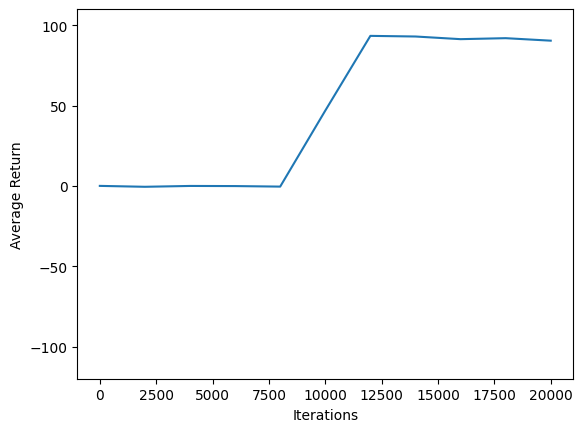

In [31]:
#@test {"skip": true}

iterations = range(0, num_iterations + 1, eval_interval)
plt.plot(iterations, returns)
plt.ylabel('Average Return')
plt.xlabel('Iterations')
plt.ylim(-120, 110)


Vemos que la divergencia inicial podia deberse a la policy o al numero de iteraciones. Tras aumentar recoleccion, suavizar el target update y escalar recompensas, DDPG se estabiliza mejor en el entorno continuo.

#### Videos

Charts are nice. But more exciting is seeing an agent actually performing a task in an environment. 

First, create a function to embed videos in the notebook.

In [32]:
def embed_mp4(filename):
  """Embeds an mp4 file in the notebook."""
  video = open(filename,'rb').read()
  b64 = base64.b64encode(video)
  tag = '''
  <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
  Your browser does not support the video tag.
  </video>'''.format(b64.decode())

  return IPython.display.HTML(tag)

Now iterate through a few episodes of the Cartpole game with the agent. The underlying Python environment (the one "inside" the TensorFlow environment wrapper) provides a `render()` method, which outputs an image of the environment state. These can be collected into a video.

In [33]:
def create_policy_eval_video(policy, filename, num_episodes=5, fps=30):
  filename = filename + ".mp4"
  with imageio.get_writer(filename, fps=fps) as video:
    for _ in range(num_episodes):
      time_step = eval_env.reset()
      video.append_data(eval_py_env.render())
      while not time_step.is_last():
        action_step = policy.action(time_step)
        time_step = eval_env.step(action_step.action)
        video.append_data(eval_py_env.render())
  return embed_mp4(filename)

create_policy_eval_video(agent.policy, "trained-agent")

[swscaler @ 0x5acd9c2043c0] Warning: data is not aligned! This can lead to a speed loss


For fun, compare the trained agent (above) to an agent moving randomly. (It does not do as well.)

In [34]:
create_policy_eval_video(random_policy, "random-agent")

[swscaler @ 0x6053fa528400] Warning: data is not aligned! This can lead to a speed loss


El agente aleatorio no comprende la necesidad de moverse primero hacia atrás para usar la física del entorno y generar el impulso necesario para subir la montaña.

En contraste, el agente entrenado desarrolla esta estrategia, logrando subir significativamente más alto y acercándose al objetivo del entorno (llegar a la cima del lado derecho). Esto valida que el modelo actor-crítico (DDPG) aprendió la dinámica continua del entorno y superó el desempeño base.

here the strategie of error is defined by someone but optimized using matrix and rewards as output into the model, this is were the machine converts into a deep learning machine 